In [1]:
from zipfile import ZipFile
file_name='/content/MIt-BIH Datasets.zip'
with ZipFile(file_name,'r') as zip:
  zip.extractall()

In [2]:
import pandas as pd
train = pd.read_csv("/content/MIt-BIH Datasets/train.csv" , header = None)
validate = pd.read_csv("/content/MIt-BIH Datasets/validate.csv" , header = None)
test = pd.read_csv("/content/MIt-BIH Datasets/test.csv" , header = None)
display_test = pd.read_csv("/content/test.csv" , header = None)


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from keras.utils.np_utils import to_categorical
from sklearn.utils import class_weight
import warnings

from keras.preprocessing.sequence import TimeseriesGenerator

from keras.models import Sequential
from keras.layers import Reshape
from keras.models import Model
from sklearn import metrics

from keras.layers import Dense, Activation, Flatten, Convolution1D, Dropout,MaxPooling1D , Input
from tensorflow.keras.optimizers import Adam 
from keras.callbacks import LearningRateScheduler

import itertools
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, label_ranking_average_precision_score, label_ranking_loss, coverage_error 

import imblearn
from collections import Counter

warnings.filterwarnings('ignore')

In [4]:
train.rename(columns={187:"Class"}, inplace=True)
test.rename(columns={187:"Class"}, inplace=True)
validate.rename(columns={187:"Class"}, inplace=True)
display_test.rename(columns={187:"Class"}, inplace=True)


In [5]:
counter = Counter(train['Class'])
print(counter)

Counter({0.0: 67368, 15.0: 5888, 2.0: 5726, 1.0: 3965, 8.0: 2852, 4.0: 1910, 17.0: 1008, 10.0: 491, 12.0: 137, 6.0: 106, 14.0: 69, 5.0: 52, 18.0: 22})


In [6]:
mapping = {    
               0 : 'Normal Beat',
               1 : 'Left bundle branch block beat',
               2 : 'Right bundle branch block beat',
               4 : 'Atrial premature beat',
               5 : 'Aberrated atrial premature beat',
               6 : 'Nodal (junctional) premature beat',
             
               8 : 'Premature ventricular contraction',
               10 : 'Fusion of ventricular and normal beat',
               
               12 : 'Nodal (junctional) escape beat',
               14 : 'Ventricular escape beat',
               15 : 'Paced beat',
             
               17 : 'Unclassifiable beat',
                18 : 'Fusion of ventricular and normal beat'

               }

In [7]:
train['label'] = train.iloc[:, -1].map(mapping)
test['label'] = test.iloc[:, -1].map(mapping)
validate['label'] = validate.iloc[:, -1].map(mapping)
display_test['label'] = display_test.iloc[:, -1].map(mapping)



In [8]:
df_15=train[train['Class']==15]
df_2=train[train['Class']==2]
df_1=train[train['Class']==1]
df_8=train[train['Class']==8]
df_4=train[train['Class']==4]
df_17=train[train['Class']==17]
df_10=train[train['Class']==10]
df_12=train[train['Class']==12]
df_6=train[train['Class']==6]
df_14=train[train['Class']==14]
df_5=train[train['Class']==5]
df_18=train[train['Class']==18]


df_0=(train[train['Class']==0]).sample(n=20000,random_state=42)


train=pd.concat([df_0,df_15,df_2,df_1,df_8,df_4,df_10,df_12,df_6,df_14,df_5,df_17,df_18])

In [9]:
tain_count_classes_resamble =train["Class"].value_counts()

In [10]:
tain_count_classes_resamble

0.0     20000
15.0     5888
2.0      5726
1.0      3965
8.0      2852
4.0      1910
17.0     1008
10.0      491
12.0      137
6.0       106
14.0       69
5.0        52
18.0       22
Name: Class, dtype: int64

In [11]:
X_train=train.iloc[:,:186].values
X_test=test.iloc[:,:186].values
X_validate = validate.iloc[: , :186].values
X_display = display_test.iloc[: , :186].values


In [12]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE(k_neighbors=2)
X_train, y_train = oversample.fit_resample(X_train, train["Class"])


In [13]:
counter = Counter(y_train)
print(counter)

Counter({0.0: 20000, 15.0: 20000, 2.0: 20000, 1.0: 20000, 8.0: 20000, 4.0: 20000, 10.0: 20000, 12.0: 20000, 6.0: 20000, 14.0: 20000, 5.0: 20000, 17.0: 20000, 18.0: 20000})


In [14]:
X_train = X_train.reshape(len(X_train), X_train.shape[1],1)
X_test = X_test.reshape(len(X_test), X_test.shape[1],1)
X_validate = X_validate.reshape(len(X_validate), X_validate.shape[1],1)
X_display = X_display.reshape(len(X_display), X_display.shape[1],1)


In [15]:
target_test=test["Class"]
target_validate=validate["Class"]
target_display = display_test["Class"]

y_train=y_train
y_test=target_test
y_validate= np.array(target_validate).reshape(-1,1)
y_display = np.array(target_display).reshape(-1,1)


In [16]:
y_train.shape

(260000,)

In [17]:
y_train= np.array(y_train).reshape(-1,1)
y_test= np.array(y_test).reshape(-1,1)
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
encoder_df1 = pd.DataFrame(enc.fit_transform(y_train).toarray())
encoder_df2 = pd.DataFrame(enc.fit_transform(y_test).toarray())
encoder_df3 = pd.DataFrame(enc.fit_transform(y_validate).toarray())
encoder_df4 = pd.DataFrame(enc.fit_transform(y_display).toarray())

y_train = np.array(encoder_df1)
y_test = np.array(encoder_df2)
y_validate = np.array(encoder_df3)
y_display = np.array(encoder_df4)

encoder_df4 = pd.DataFrame(enc.fit_transform(y_display).toarray())


In [18]:
y_validate.shape

(29865, 13)

In [19]:
X_validate.shape

(29865, 186, 1)

In [20]:
y_train.shape

(260000, 13)

In [21]:
y_test.shape

(29865, 13)

In [22]:
class_labels_ytr = np.argmax(y_train, axis=1)
class_labels_yte = np.argmax(y_test, axis=1)
class_labels_yva = np.argmax(y_validate, axis=1)



In [23]:
X_validate.shape

(29865, 186, 1)

In [24]:
y_train.shape

(260000, 13)

In [25]:
X_train.shape

(260000, 186, 1)

In [26]:
X_test.shape

(29865, 186, 1)

In [27]:
y_test.shape

(29865, 13)

In [28]:
y_train.shape

(260000, 13)

In [29]:
print(y_train.shape)
print(X_train.shape)
print(y_test.shape)
print(X_test.shape)
print(X_validate.shape)
print(y_validate.shape)
print(X_display.shape)
print(y_display.shape)

(260000, 13)
(260000, 186, 1)
(29865, 13)
(29865, 186, 1)
(29865, 186, 1)
(29865, 13)
(32, 186, 1)
(32, 15)


In [30]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM , CuDNNLSTM
from keras.layers import Dropout
import keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold , StratifiedKFold
import numpy as np
from keras.layers import Input, Dense, Conv1D, MaxPooling1D, Softmax, Add, Flatten, Activation# , Dropout


In [31]:
adam = Adam(lr = 0.001, beta_1 = 0.9, beta_2 = 0.999)

In [32]:
from tensorflow.keras.callbacks import ModelCheckpoint
my_callbacks = [
#    keras.callbacks.EarlyStopping(monitor='val_loss' , patience=8),
    ModelCheckpoint(filepath='residual_kfold.h5' , monitor = 'val_loss' , save_best_only=True),
    
]

In [33]:
acc_per_fold = []
loss_per_fold = []
n_obs, feature, depth = X_train.shape
batch_size = 500
inputs = np.concatenate((X_train, X_test), axis=0)
targets = np.concatenate((y_train, y_test), axis=0)

# Define the Stratified K-fold Cross Validator
kf  = KFold(n_splits=5, shuffle=True)

# Stratified K-fold Cross Validation model evaluation
fold_no = 1
for train, test in kf.split(inputs, np.argmax(targets,axis=1)):

  # Define the model architecture
  inp = Input(shape=(feature, depth))
  C = Conv1D(filters=32, kernel_size=5, strides=1)(inp)
  C11 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(C)
  A11 = Activation("relu")(C11)

  C12 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A11)
  S11 = Add()([C12, C])
  A12 = Activation("relu")(S11)
  M11 = MaxPooling1D(pool_size=5, strides=2)(A12)


  C21 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M11)
  A21 = Activation("relu")(C21)
  C22 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A21)
  S21 = Add()([C22, M11])
  A22 = Activation("relu")(S11)
  M21 = MaxPooling1D(pool_size=5, strides=2)(A22)


  C31 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M21)
  A31 = Activation("relu")(C31)
  C32 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A31)
  S31 = Add()([C32, M21])
  A32 = Activation("relu")(S31)
  M31 = MaxPooling1D(pool_size=5, strides=2)(A32)


  C41 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M31)
  A41 = Activation("relu")(C41)
  C42 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A41)
  S41 = Add()([C42, M31])
  A42 = Activation("relu")(S41)
  M41 = MaxPooling1D(pool_size=5, strides=2)(A42)


  C51 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M41)
  A51 = Activation("relu")(C51)
  C52 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A51)
  S51 = Add()([C52, M41])
  A52 = Activation("relu")(S51)
  M51 = MaxPooling1D(pool_size=5, strides=2)(A52)

  F1 = Flatten()(M51)

  D1 = Dense(32)(F1)
  A6 = Activation("relu")(D1)
  D2 = Dense(32)(A6)
  D3 = Dense(13)(D2)
  A7 = Softmax()(D3)

  model = Model(inputs=inp, outputs=A7)
  model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])
  # Generate a print
  print('------------------------------------------------------------------------')
  print(f'Training for fold {fold_no} ...')

  # Fit data to model
  history = model.fit(inputs[train], targets[train],
              batch_size=500,
              validation_data=(X_validate, y_validate),
              epochs=20,
              verbose=1,callbacks=my_callbacks)

  # Generate generalization metrics
  scores = model.evaluate(X_test, y_test, verbose=0)
  print(f'Score for fold {fold_no}: {model.metrics_names[0]} of {scores[0]}; {model.metrics_names[1]} of {scores[1]*100}%')
  acc_per_fold.append(scores[1] * 100)
  loss_per_fold.append(scores[0])

  # Increase fold number
  fold_no = fold_no + 1

------------------------------------------------------------------------
Training for fold 1 ...
Epoch 1/20
464/464 [==============================] - 20s 17ms/step - loss: 0.5784 - accuracy: 0.8104 - val_loss: 0.2294 - val_accuracy: 0.9283
Epoch 2/20
464/464 [==============================] - 7s 15ms/step - loss: 0.1589 - accuracy: 0.9508 - val_loss: 0.1901 - val_accuracy: 0.9431
Epoch 3/20
464/464 [==============================] - 7s 15ms/step - loss: 0.1042 - accuracy: 0.9675 - val_loss: 0.1982 - val_accuracy: 0.9373
Epoch 4/20
464/464 [==============================] - 7s 15ms/step - loss: 0.0815 - accuracy: 0.9743 - val_loss: 0.1725 - val_accuracy: 0.9442
Epoch 5/20
464/464 [==============================] - 7s 15ms/step - loss: 0.0645 - accuracy: 0.9795 - val_loss: 0.1041 - val_accuracy: 0.9683
Epoch 6/20
464/464 [==============================] - 7s 15ms/step - loss: 0.0554 - accuracy: 0.9819 - val_loss: 0.1042 - val_accuracy: 0.9685
Epoch 7/20
464/464 [========================

In [34]:
y_pred = model.predict(X_test, batch_size=1000)

In [35]:
y_pred=np.argmax(y_pred, axis=1)

In [36]:
yyy_test = np.argmax(y_test , axis = 1)

In [37]:
print("Model Accuracy is : " , accuracy_score(yyy_test, y_pred) )

Model Accuracy is :  0.9863050393437134


In [38]:
print(classification_report(yyy_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     22457
           1       0.99      1.00      1.00      1274
           2       1.00      1.00      1.00      1986
           3       0.87      0.93      0.90       618
           4       0.70      0.95      0.81        22
           5       0.85      1.00      0.92        22
           6       0.96      0.97      0.96       982
           7       0.73      0.89      0.81       169
           8       0.98      0.96      0.97        54
           9       1.00      1.00      1.00        26
          10       0.99      0.98      0.99      1932
          11       0.73      0.96      0.83       320
          12       0.43      1.00      0.60         3

    accuracy                           0.99     29865
   macro avg       0.86      0.97      0.91     29865
weighted avg       0.99      0.99      0.99     29865



In [39]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')



Confusion matrix, without normalization


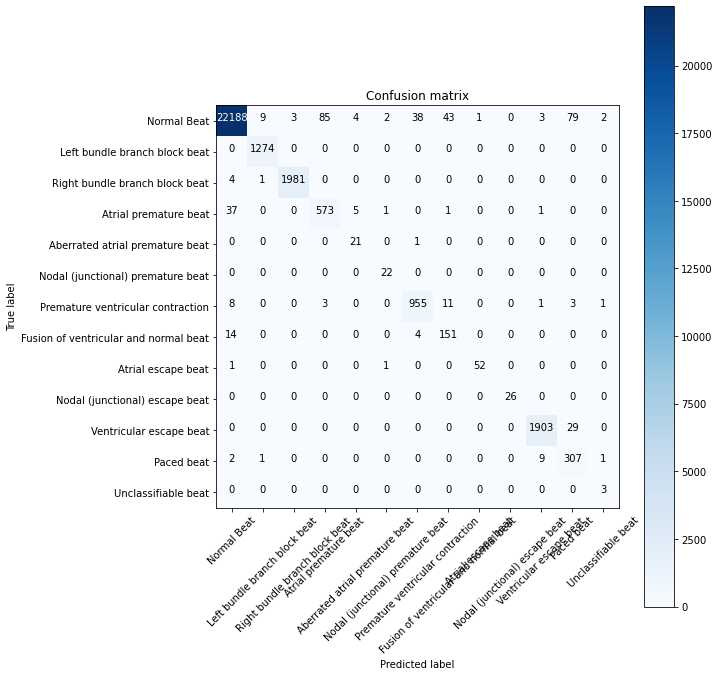

In [40]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(yyy_test, y_pred)

# Plot non-normalized confusion matrix
plt.figure(figsize=(10, 10))
plot_confusion_matrix(cnf_matrix, classes=[
                                           
                'Normal Beat',
                'Left bundle branch block beat',
                'Right bundle branch block beat',
                'Atrial premature beat',
                'Aberrated atrial premature beat',
                'Nodal (junctional) premature beat',
                'Premature ventricular contraction',
                'Fusion of ventricular and normal beat',
                'Atrial escape beat',
                'Nodal (junctional) escape beat',
                'Ventricular escape beat',
                'Paced beat',
                'Unclassifiable beat'

],
                      title='Confusion matrix')
plt.show()

In [41]:
from numpy import std
# Accuracy in Stratified K Fold
acc_per_fold

[97.76996374130249,
 98.13494086265564,
 99.05909895896912,
 98.90841841697693,
 98.63050580024719]

In [42]:
from statistics import mean
print('mean in accuracy: ')
mean(acc_per_fold)

mean in accuracy: 


98.50058555603027

In [43]:
print('min value element in accuracy: ')
min(acc_per_fold)

min value element in accuracy: 


97.76996374130249

In [44]:
print("Max value element in accuracy : ")
max(acc_per_fold)

Max value element in accuracy : 


99.05909895896912

In [45]:
import statistics
st_dev = statistics.pstdev(acc_per_fold)
print("Standard deviation for Accuracy: " + str(st_dev))

Standard deviation for Accuracy: 0.48221331618626895


In [46]:
# loss in Stratified K Fold
loss_per_fold

[0.08014369010925293,
 0.06369896978139877,
 0.03562401980161667,
 0.04046306386590004,
 0.047443777322769165]

In [47]:
print('mean in loss: ')
mean(loss_per_fold)

mean in loss: 


0.053474704176187514

In [48]:
print('min value element in loss: ')
min(loss_per_fold)

min value element in loss: 


0.03562401980161667

In [49]:
print("Max value element in loss: ")
max(loss_per_fold)

Max value element in loss: 


0.08014369010925293

In [50]:
import statistics
st_dev = statistics.pstdev(loss_per_fold)
print("Standard deviation for loss: " + str(st_dev))

Standard deviation for loss: 0.016371268813259864


In [51]:
fpr, tpr, thresholds = metrics.roc_curve(yyy_test, y_pred, pos_label=2)

In [52]:
print(fpr)

[0.00000000e+00 2.51085046e-04 1.52444492e-02 8.40058826e-02
 8.49384842e-02 8.68395567e-02 9.42286309e-02 1.30026185e-01
 1.30958786e-01 1.32034865e-01 1.55744467e-01 1.55852075e-01
 2.01908246e-01 1.00000000e+00]


In [53]:
print(tpr)

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.99748238
 0.9979859  1.        ]


In [54]:
print(thresholds)

[13 12 11 10  9  8  7  6  5  4  3  2  1  0]


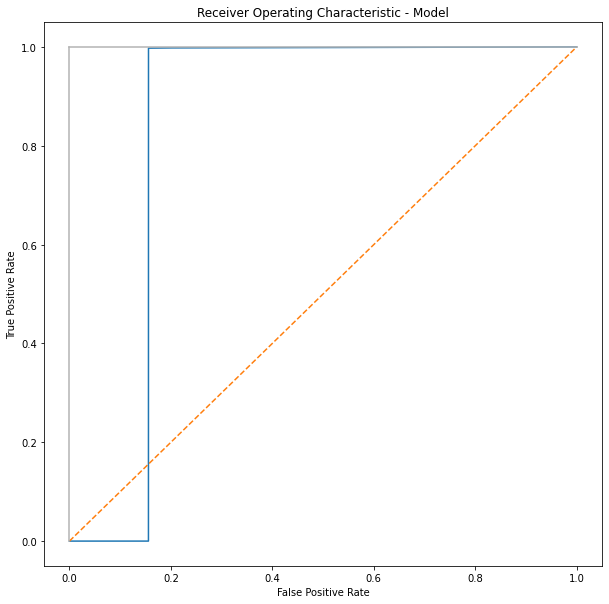

In [55]:
plt.subplots(1, figsize=(10,10))
plt.title('Receiver Operating Characteristic - Model')
plt.plot(fpr, tpr)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [56]:

auc = metrics.auc(fpr, tpr)
print("Auc is : ")
print(auc )


Auc is : 
0.8432935187801031


In [57]:
import tensorflow.keras.backend as K
import tensorflow as tf
tf.compat.v1.disable_eager_execution()
#tf.compat.v1.reset_default_graph()


run_eagerly = True



def gradcam(model, x, index, layer_name):
    # 取得影像的分類類別
    #with tf.Graph().as_default():
    model = tf.keras.models.load_model('./residual_kfold.h5')
    preds = model.predict(x)
    #model._make_predict_function()
    pred_class = np.argmax(preds[index])
    
    # 取得影像分類名稱
    #pred_class_name = imagenet_utils.decode_predictions(preds)[0][0][1]
    
    # 預測分類的輸出向量
    pred_output = model.output[:, pred_class]
    
    # 最後一層 convolution layer 輸出的 feature map
    # ResNet 的最後一層 convolution layer
    last_conv_layer = model.get_layer(layer_name)
    
    # 求得分類的神經元對於最後一層 convolution layer 的梯度
    grads = K.gradients(pred_output, last_conv_layer.output)[0]
    
    # 求得針對每個 feature map 的梯度加總
    #pooled_grads = K.sum(grads, axis=(0, 1, 2))
    pooled_grads = K.sum(grads, axis=(0, 1))
    
    # K.function() 讓我們可以藉由輸入影像至 `model.input` 得到 `pooled_grads` 與
    # `last_conv_layer[0]` 的輸出值，像似在 Tensorflow 中定義計算圖後使用 feed_dict
    # 的方式。
    iterate = K.function([model.input], [pooled_grads, last_conv_layer.output[index]])
    
    # 傳入影像矩陣 x，並得到分類對 feature map 的梯度與最後一層 convolution layer 的 
    # feature map
    pooled_grads_value, conv_layer_output_value = iterate([x])
    
    # 將 feature map 乘以權重，等於該 feature map 中的某些區域對於該分類的重要性
    for i in range(pooled_grads_value.shape[0]):
        conv_layer_output_value[:, i] *= (pooled_grads_value[i])
        
    # 計算 feature map 的 channel-wise 加總
    heatmap = np.sum(conv_layer_output_value, axis=-1)
    
    return heatmap, pred_class

In [58]:
def heatmap_():
    heatmap_2d = np.expand_dims(heatmap,1)
    heatmap_2d = cv2.resize(heatmap_2d, (100,188))

    figure = plt.figure(figsize=(80,4))
    ax = figure.add_subplot(111)
    x = np.arange(0, 188, 1)
    ax.plot(x, data*100)
    ax.imshow(np.transpose(heatmap_2d), cmap="Oranges", extent=[0, 188, -10, 120])
    ax.autoscale(False)
    ax.set_xlim(0, 187)
    ax.set_ylim(-10, 110)
    ax.set_title(title)
    plt.show()

In [59]:
layer_name=[]
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.output_shape)
    layer_name.append(layer.name)

0 input_5 [(None, 186, 1)]
1 conv1d_44 (None, 182, 32)
2 conv1d_45 (None, 182, 32)
3 activation_44 (None, 182, 32)
4 conv1d_46 (None, 182, 32)
5 add_20 (None, 182, 32)
6 activation_47 (None, 182, 32)
7 max_pooling1d_21 (None, 89, 32)
8 conv1d_49 (None, 89, 32)
9 activation_48 (None, 89, 32)
10 conv1d_50 (None, 89, 32)
11 add_22 (None, 89, 32)
12 activation_49 (None, 89, 32)
13 max_pooling1d_22 (None, 43, 32)
14 conv1d_51 (None, 43, 32)
15 activation_50 (None, 43, 32)
16 conv1d_52 (None, 43, 32)
17 add_23 (None, 43, 32)
18 activation_51 (None, 43, 32)
19 max_pooling1d_23 (None, 20, 32)
20 conv1d_53 (None, 20, 32)
21 activation_52 (None, 20, 32)
22 conv1d_54 (None, 20, 32)
23 add_24 (None, 20, 32)
24 activation_53 (None, 20, 32)
25 max_pooling1d_24 (None, 8, 32)
26 flatten_4 (None, 256)
27 dense_12 (None, 32)
28 activation_54 (None, 32)
29 dense_13 (None, 32)
30 dense_14 (None, 13)
31 softmax_4 (None, 13)


In [60]:
def heatmap_3x():
    def preprocess_heatmap(heatmap):
        heatmap_2d = np.expand_dims(heatmap,1)
        heatmap_2d = cv2.resize(heatmap_2d, (100,186))
        heatmap_2d = np.transpose(heatmap_2d)
        return heatmap_2d

    fig, ax = plt.subplots(1,len(name_list)+1,figsize=(20,4))
    x = np.arange(0, 186, 1)
    Collect_attention = list()
    for i in range(1,len(name_list)+1):
        ax[i].plot(x, data*100)
        heatmap_2d = preprocess_heatmap(Collect_heatmap[i-1])
        Collect_attention.append(heatmap_2d[0])
        ax[i].imshow(heatmap_2d, cmap="Oranges", extent=[0, 186, -10, 120])
        ax[i].set_xlim(0, 187)
        ax[i].set_ylim(-10, 110)
        ax[i].set_title(name_list[i-1])
    ax[0].plot(x, data, label="ECG")
    for i in range(len(name_list)):
        ax[0].set_title(title)
        ax[0].plot(x, Collect_attention[i]/np.max(Collect_attention[i]), label=name_list[i])
        ax[0].set_ylim(-0.2, 1)
    ax[0].legend()

    plt.show()

In [61]:
X_display = np.array(X_display).astype(float)

In [62]:
from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()
y_display = y_display

In [63]:
len(X_display)

32

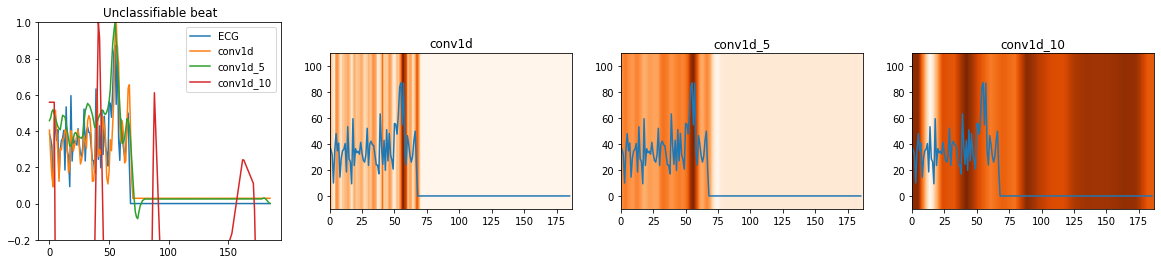

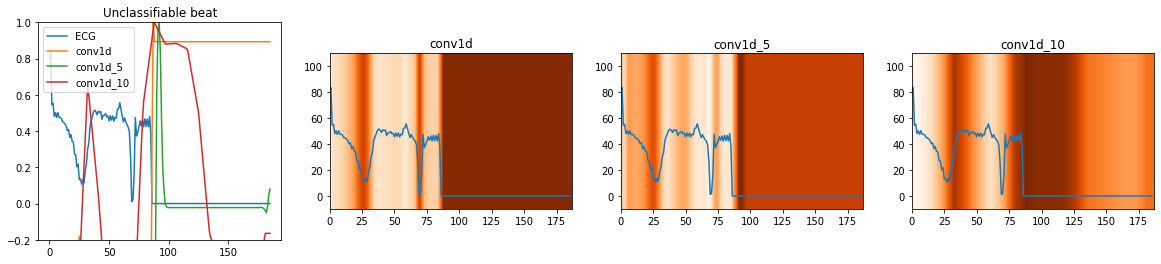

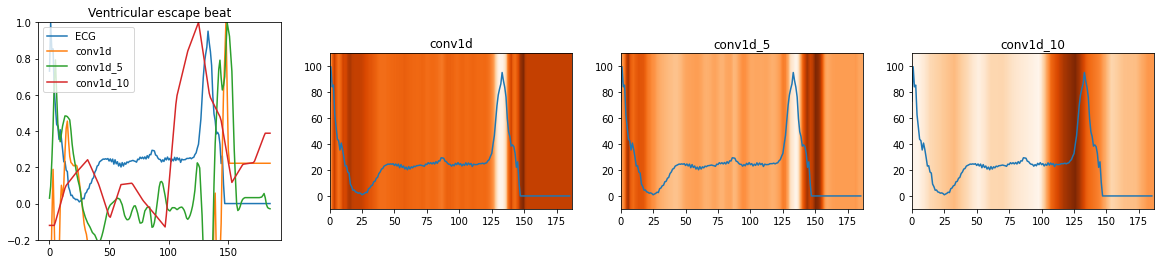

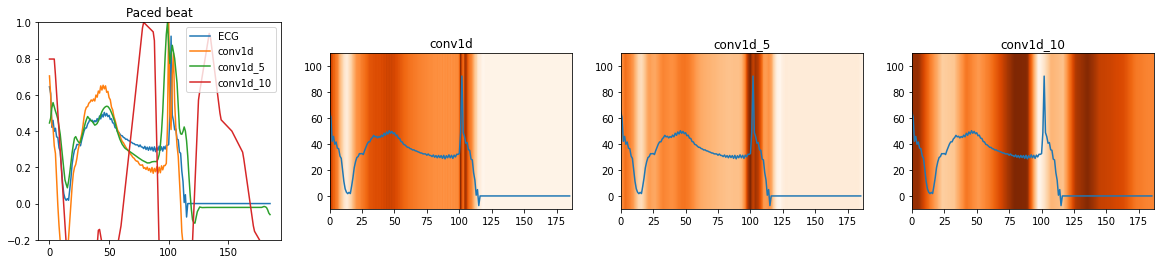

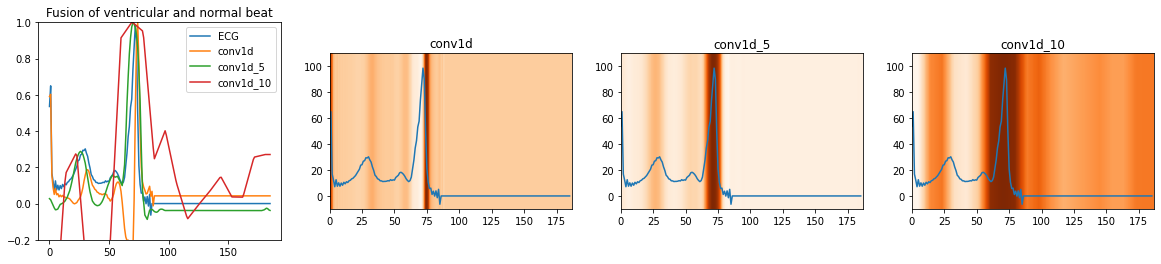

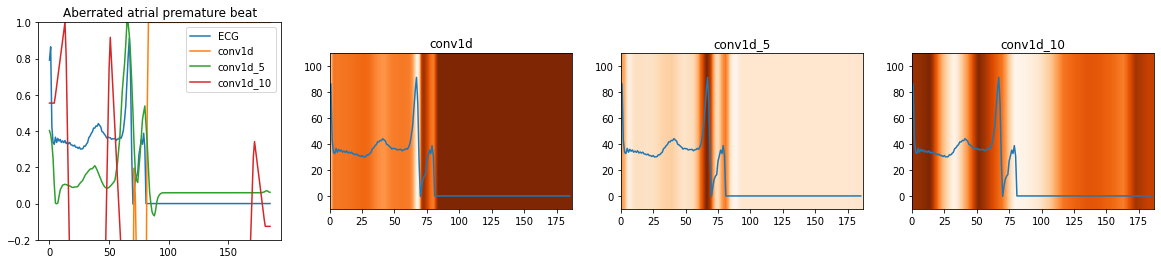

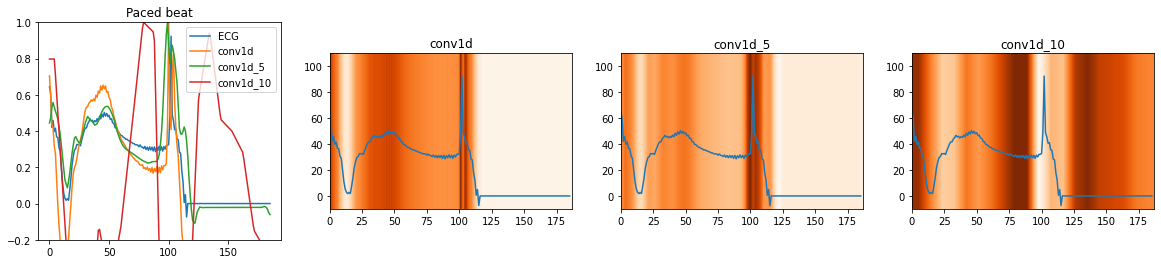

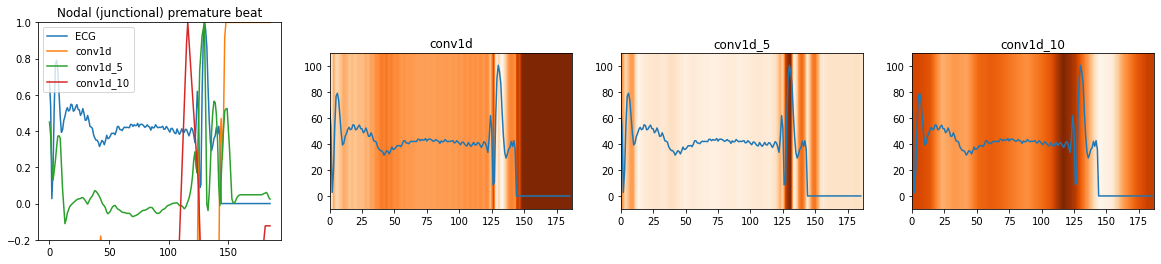

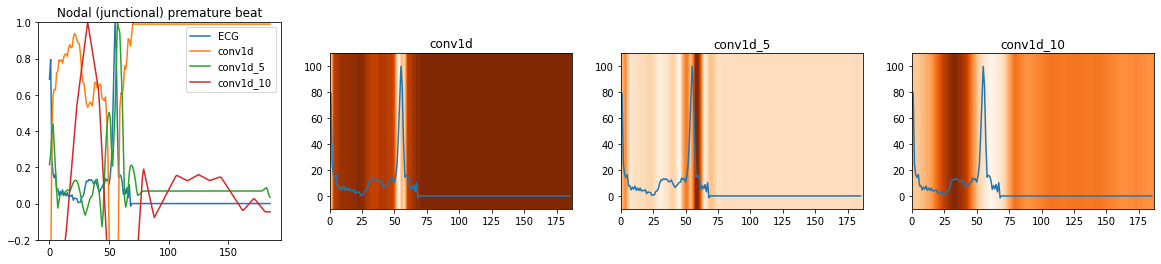

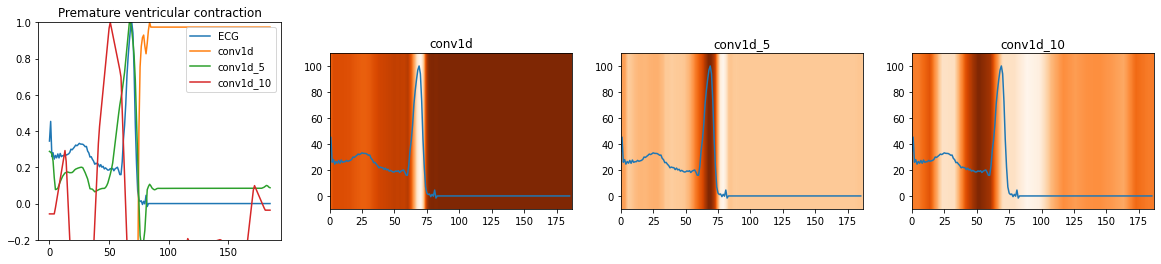

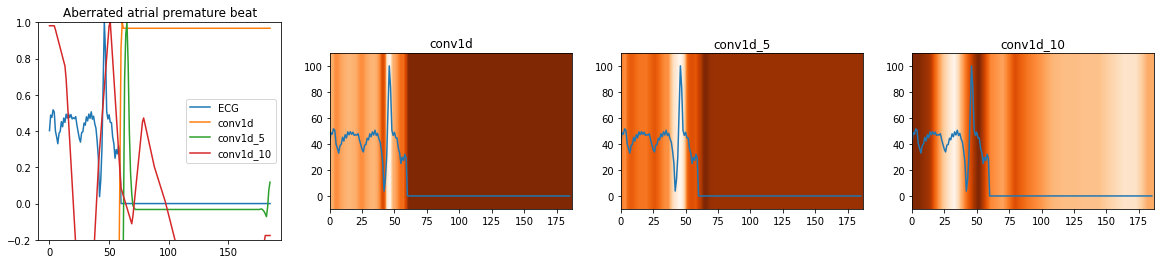

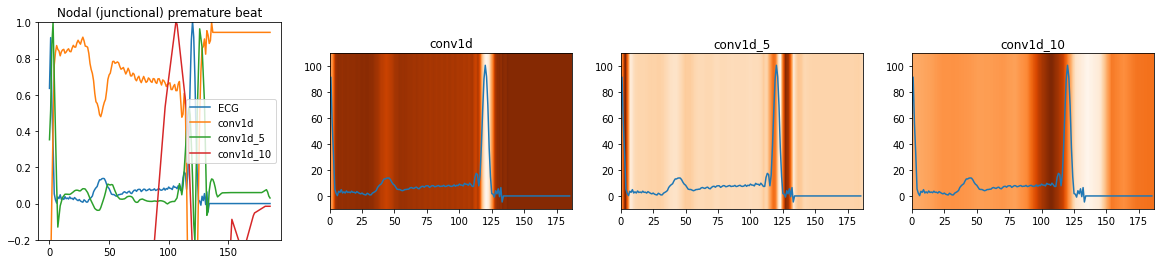

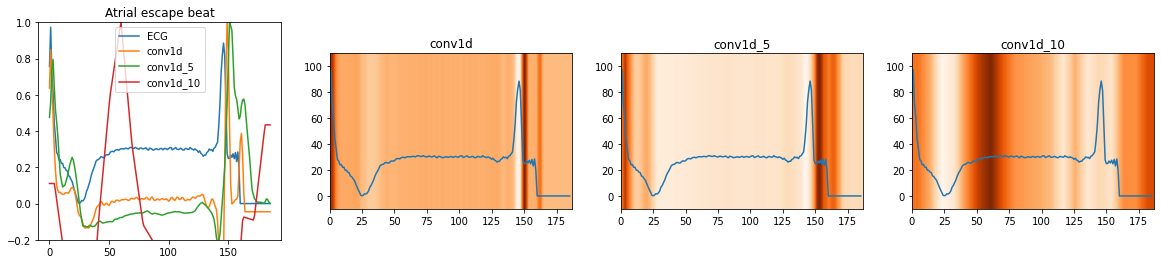

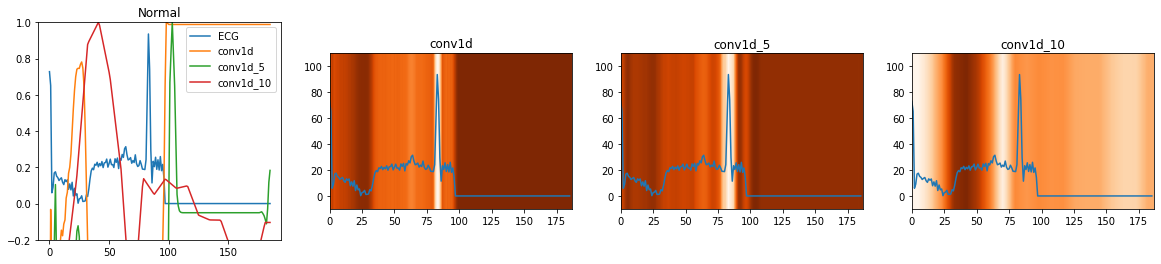

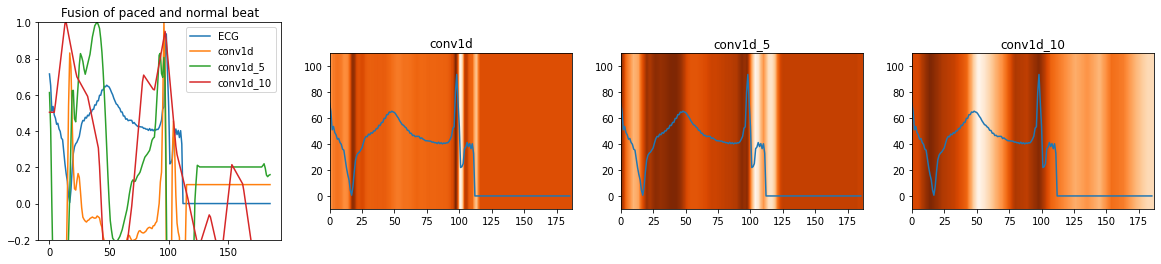

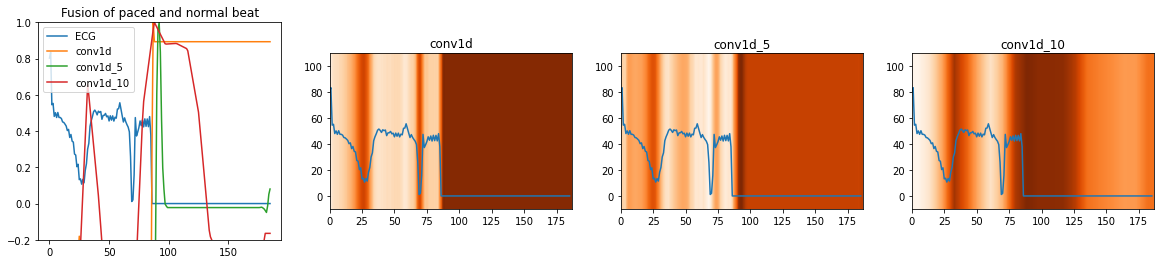

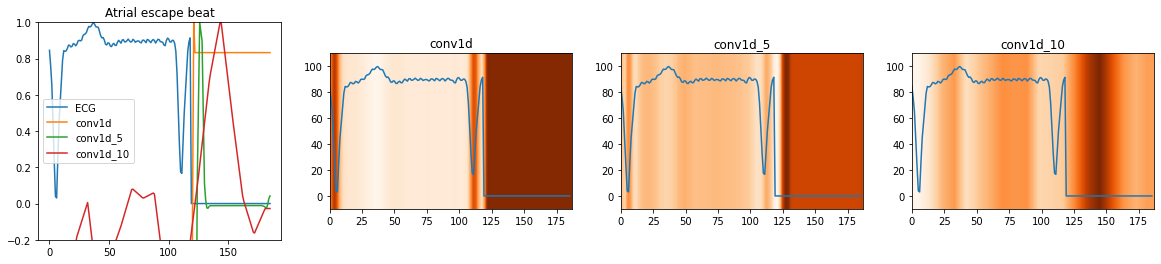

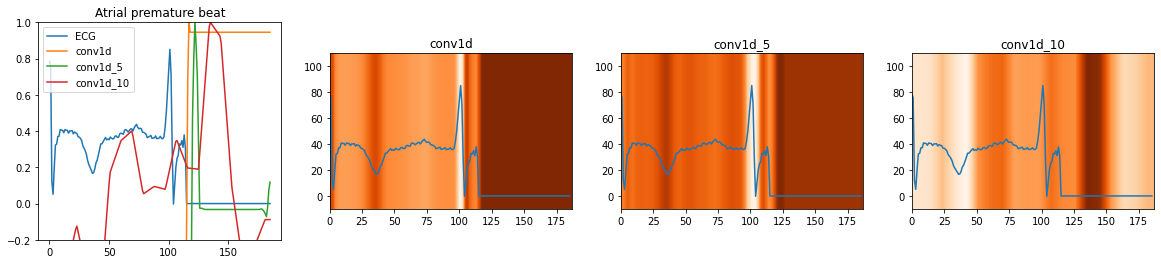

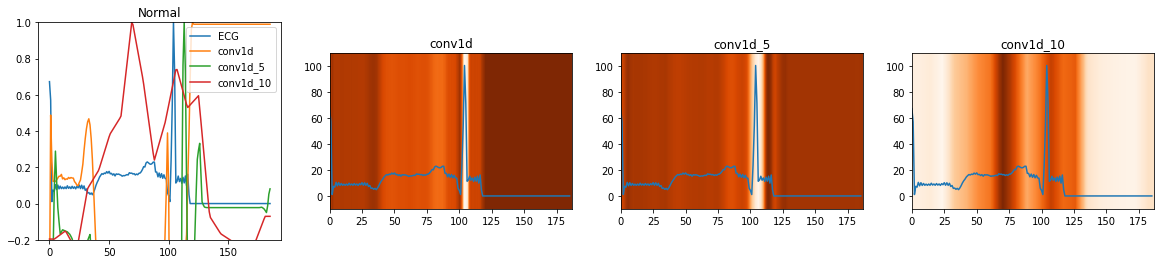

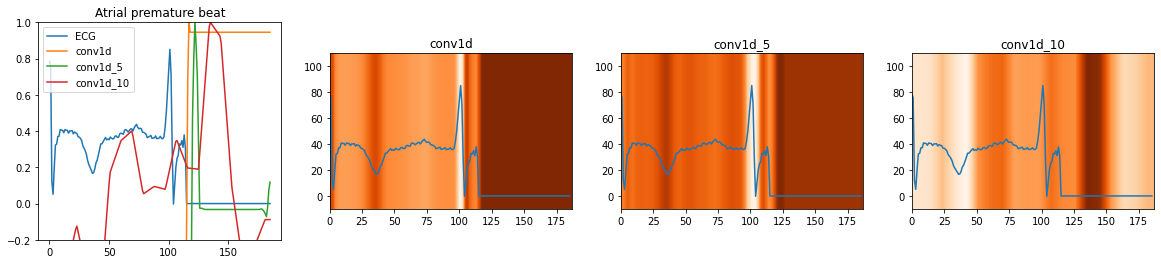

In [64]:
import cv2
for i in range(20):
    Collect_heatmap = list()
    index = np.random.randint(0,len(X_display))
    name_list = ['conv1d','conv1d_5','conv1d_10']
    for name in name_list:
      heatmap, pred_class = gradcam(model, X_display, index, name)
      Collect_heatmap.append(heatmap)
    data = X_display[index]
    if int(y_display[index][0]==1): 
      title = "Normal"
    elif int(y_display[index][1]==1):
      title = "Left bundle branch block beat"
    elif int(y_display[index][2]==1):
      title = "Right bundle branch block beat"
    elif int(y_display[index][3]==1):
      title = "Atrial premature beat"
    elif int(y_display[index][4]==1):
      title = "Aberrated atrial premature beat"
    elif int(y_display[index][5]==1):
      title = "Nodal (junctional) premature beat"
    elif int(y_display[index][7]==1):
      title = "Premature ventricular contraction"
    elif int(y_display[index][8]==1):
      title = "Fusion of ventricular and normal beat"
    elif int(y_display[index][9]==1):
      title = "Atrial escape beat"
    elif int(y_display[index][10]==1):
      title = "Nodal (junctional) escape beat"
    elif int(y_display[index][11]==1):
      title = "Ventricular escape beat"
    elif int(y_display[index][12]==1):
      title = "Paced beat"
    elif int(y_display[index][13]==1):
      title = "Fusion of paced and normal beat"
    elif int(y_display[index][14]==1):
      title = "Unclassifiable beat"
   
    heatmap_3x()